# 05 — ML Baseline vs Rule-Based AML
## Gaming Compliance & Risk Intelligence Platform

A **supervised machine-learning baseline** (logistic regression) for laundering
detection, compared head-to-head with the rule-based engine (Phase 5) on the **same
held-out test set**. This shows ML as a complement to — not a replacement for — the
explainable rules a regulator expects.

> Fair-comparison note: `Sanctions_Flag` / `PEP_Flag` are **excluded** from the ML
> features (sanctions is effectively a label) so the model is judged on *behavioural*
> signals, the same basis as the behavioural rules.


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix)

df = pd.read_csv("../data_processed/transactions_clean.csv", parse_dates=["Timestamp"])
df = df.reset_index().rename(columns={"index": "Transaction_ID"})
alerts = pd.read_csv("../data_processed/aml_alerts.csv")
print(f"{len(df):,} transactions | laundering rate {df.Is_Laundering.mean():.2%}")


5,401 transactions | laundering rate 9.05%


## 1. Feature Engineering (behavioural only)

In [2]:
df["log_amount"] = np.log1p(df.Amount_Paid)
df["acct_txn_count"] = df.groupby("From_Account").Transaction_ID.transform("count")
df["acct_avg_amount"] = df.groupby("From_Account").Amount_Paid.transform("mean")

feat = df[["Amount_Paid","log_amount","Transaction_Hour","acct_txn_count",
           "acct_avg_amount","Payment_Format","Transaction_Type"]]
X = pd.get_dummies(feat, columns=["Payment_Format","Transaction_Type"], drop_first=True)
y = df.Is_Laundering
print("Feature matrix:", X.shape)
list(X.columns)


Feature matrix: (5401, 11)


['Amount_Paid',
 'log_amount',
 'Transaction_Hour',
 'acct_txn_count',
 'acct_avg_amount',
 'Payment_Format_Credit Card',
 'Payment_Format_Crypto',
 'Payment_Format_Debit Card',
 'Payment_Format_Interac e-Transfer',
 'Payment_Format_Prepaid Card',
 'Transaction_Type_Withdrawal']

## 2. Train / Test Split & Model

In [3]:
X_tr, X_te, y_tr, y_te, id_tr, id_te = train_test_split(
    X, y, df.Transaction_ID, test_size=0.30, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_tr)
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(scaler.transform(X_tr), y_tr)

proba = clf.predict_proba(scaler.transform(X_te))[:, 1]
pred = (proba >= 0.5).astype(int)
print(f"Test set: {len(y_te):,} transactions ({y_te.sum()} laundering)")


Test set: 1,621 transactions (147 laundering)


## 3. ML Performance (test set)

In [4]:
ml = dict(Precision=precision_score(y_te, pred), Recall=recall_score(y_te, pred),
          F1=f1_score(y_te, pred), ROC_AUC=roc_auc_score(y_te, proba))
for k, v in ml.items():
    print(f"{k:10}: {v:.3f}")


Precision : 0.593
Recall    : 0.864
F1        : 0.704
ROC_AUC   : 0.976


## 4. Rule-Based Performance (same test set)

In [5]:
flagged_ids = set(alerts.Transaction_ID)
rule_pred = id_te.isin(flagged_ids).astype(int).values
rb = dict(Precision=precision_score(y_te, rule_pred), Recall=recall_score(y_te, rule_pred),
          F1=f1_score(y_te, rule_pred), ROC_AUC=np.nan)  # rules are binary, no score
for k, v in rb.items():
    print(f"{k:10}: {v:.3f}" if not np.isnan(v) else f"{k:10}: n/a")


Precision : 0.874
Recall    : 0.993
F1        : 0.930
ROC_AUC   : n/a


## 5. Comparison

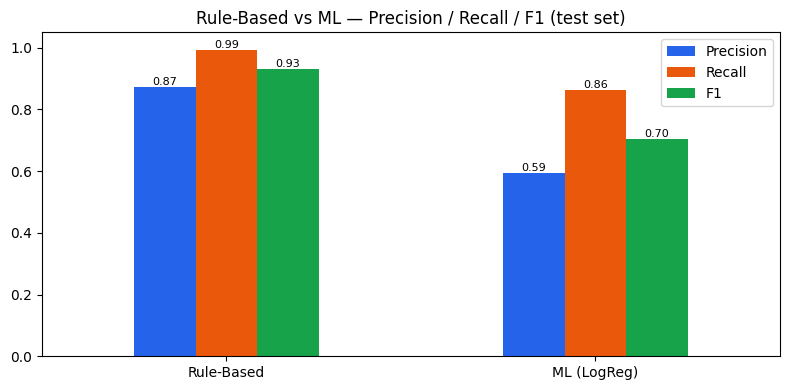

,Precision,Recall,F1
Rule-Based,0.874,0.993,0.930
ML (LogReg),0.593,0.864,0.704


In [6]:
cmp = pd.DataFrame({"Rule-Based": rb, "ML (LogReg)": ml}).T[["Precision","Recall","F1"]]
ax = cmp.plot(kind="bar", figsize=(8,4), color=["#2563eb","#ea580c","#16a34a"])
ax.set_title("Rule-Based vs ML — Precision / Recall / F1 (test set)")
ax.set_ylim(0,1.05); ax.tick_params(axis="x", rotation=0)
for c in ax.containers: ax.bar_label(c, fmt="%.2f", fontsize=8)
plt.tight_layout(); plt.show()
cmp.round(3)


### ROC curve (ML)

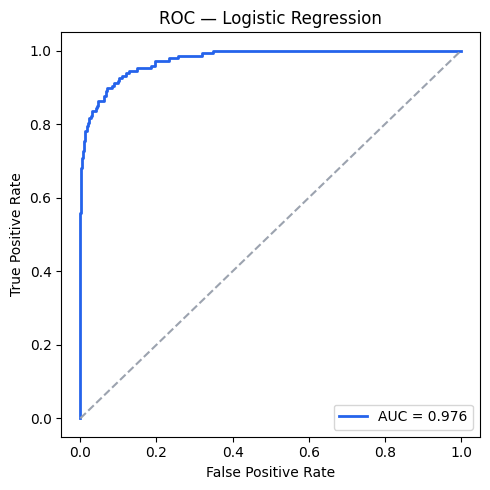

In [7]:
fpr, tpr, _ = roc_curve(y_te, proba)
fig, ax = plt.subplots(figsize=(5,5))
ax.plot(fpr, tpr, color="#2563eb", lw=2, label=f"AUC = {ml['ROC_AUC']:.3f}")
ax.plot([0,1],[0,1], "--", color="#9ca3af")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC — Logistic Regression"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


### Top behavioural features (model coefficients)

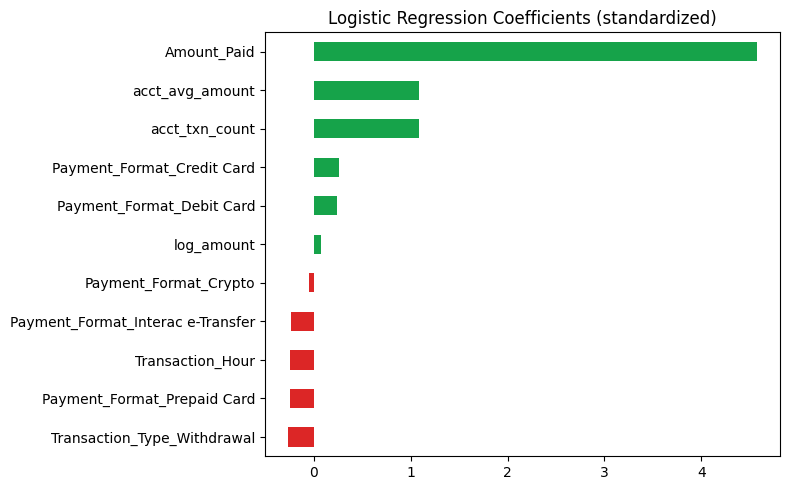

In [8]:
coef = pd.Series(clf.coef_[0], index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(8,5))
coef.plot(kind="barh", ax=ax, color=["#dc2626" if v<0 else "#16a34a" for v in coef])
ax.set_title("Logistic Regression Coefficients (standardized)")
plt.tight_layout(); plt.show()


## 6. Takeaways

- The rules deliver **very high recall** on these typologies (they were authored for
  them); the ML model independently learns **amount, velocity, and payment-method**
  signals and provides a **continuous risk probability** (ROC-AUC) rather than a
  binary flag.
- **Best practice is hybrid:** keep the transparent, regulator-explainable rules as
  the backbone, and use ML to (a) rank/prioritize alerts by probability and (b) surface
  novel patterns the rules miss — then route only the highest-probability items to
  analysts to cut false positives.
- Caveat: metrics are inflated by the synthetic data (rules and injected typologies are
  aligned); on production data both would be lower and require tuning. See the
  validation caveat in `documentation/final_report.md`.
